# Modeling EUR/CNY volatility, comparing to EUR/USD volatility

Scope of the analysis:
- topic analized : EUR/CNY (spot)
- benchmark : EUR/USD

Period : 01/01/2010-12/31/2025

Frequency : daily

**Sources :**
- Investing.com : EUR/CNY Historical Data and EUR/USD Historical Data

## EUR/CNY Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the file "EUR_CNY Historical Data", i.e. EUR/CNY (spot)

file_path = r"C:\Users\leler\Documents\Modeling EUR_CNY\EUR_CNY Historical Data.csv"

df = pd.read_csv(file_path)
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2025,8.2145,8.2193,8.2332,8.1890,NaN,-0.06%
1,12/30/2025,8.2193,8.2447,8.2505,8.2159,NaN,-0.35%
2,12/29/2025,8.2478,8.2476,8.2685,8.2313,NaN,-0.01%
3,12/26/2025,8.2487,8.2537,8.2662,8.2403,NaN,-0.04%
4,12/25/2025,8.2519,8.2657,8.2660,8.2480,NaN,-0.13%


In [3]:
df['Date'] = pd.to_datetime(df['Date']) #create colum "Date"
df = df.sort_values('Date') #sort dates from oldest to newest
df = df.reset_index(drop=True)

In [4]:
df.rename(columns={'Price': 'Spot'}, inplace=True) # create colums "Spot" (corresponding to the price)

# Daily log return of the EUR/CNY exchange rate
df['return'] = np.log(df['Spot'] / df['Spot'].shift(1))
df = df.dropna(subset=['return'])
df.head()

,Date,Spot,Open,High,Low,Vol.,Change %,return
1,2010-01-04,9.8395,9.7804,9.8716,9.7346,NaN,0.64%,0.006403
2,2010-01-05,9.8059,9.8392,9.8902,9.8074,NaN,-0.34%,-0.003421
3,2010-01-06,9.8385,9.8074,9.8499,9.7524,NaN,0.33%,0.003319
4,2010-01-07,9.7756,9.8389,9.8587,9.7624,NaN,-0.64%,-0.006414
5,2010-01-08,9.8403,9.7783,9.8522,9.7380,NaN,0.66%,0.006597


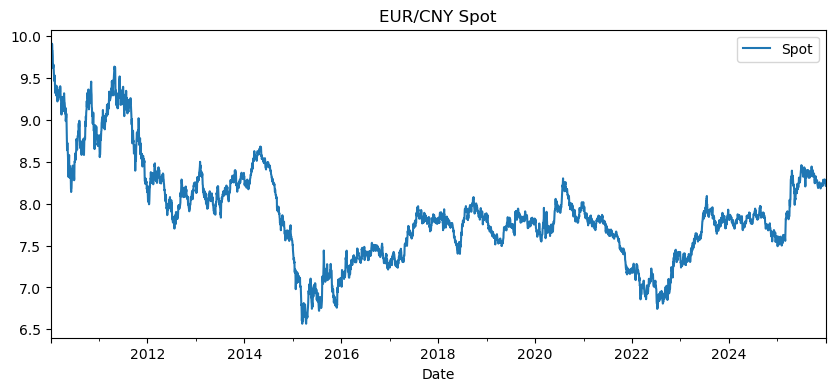

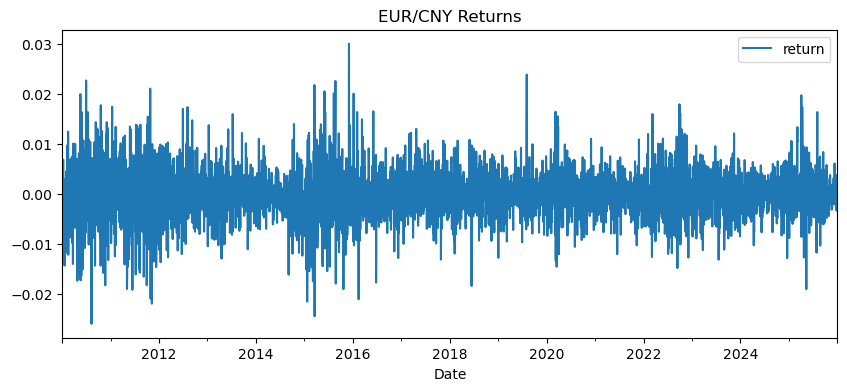

In [5]:
#EUR/CNY exchange rate over time
df.plot(x='Date', y='Spot', title='EUR/CNY Spot', figsize=(10,4))
plt.show()

#daily returns (%) over time
df.plot(x='Date', y='return', title='EUR/CNY Returns', figsize=(10,4))
plt.show()

**Conclusion**

- EUR/CNY Spot : From 2011 to 2015, the euro weakened sharply against the yuan (the line falls). Around 2015–2016, the rate bottomed near 6.6 CNY per EUR, then recovered to around 8 CNY. After 2020, the pattern alternates between appreciation and depreciation phases.
These movements reflect major macro events — RMB reform (2015), COVID‑19, and post‑pandemic monetary tightening.
You can mention that the series is non‑stationary (it drifts over time), which is why you later model returns, not prices.

- EUR/CNY Returns : The periods 2011–2013, 2015–2016 and 2020 have large spikes  (volatity change overtime) while most returns are around zero. Hence large shocks occur more often than a Normal distribution would predict.

We will use a *GARCH(1,1) model with a Student-t distribution*.


In [6]:
clean_path = r"C:\Users\leler\Documents\Modeling EUR_CNY\eur_cny_clean.csv"
df.to_csv(clean_path, index=False)
clean_path = r"C:\Users\leler\Documents\Modeling EUR_CNY\eur_cny_clean.csv"
df.to_csv(clean_path, index=False)

#### GARCH(1,1) Model of EUR/CNY

In [7]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [8]:
from arch import arch_model

In [9]:
file_path = r"C:\Users\leler\Documents\Modeling EUR_CNY\eur_cny_clean.csv"
df = pd.read_csv(file_path, parse_dates=['Date'])
df.head()

,Date,Spot,Open,High,Low,Vol.,Change %,return
0,2010-01-04,9.8395,9.7804,9.8716,9.7346,NaN,0.64%,0.006403
1,2010-01-05,9.8059,9.8392,9.8902,9.8074,NaN,-0.34%,-0.003421
2,2010-01-06,9.8385,9.8074,9.8499,9.7524,NaN,0.33%,0.003319
3,2010-01-07,9.7756,9.8389,9.8587,9.7624,NaN,-0.64%,-0.006414
4,2010-01-08,9.8403,9.7783,9.8522,9.7380,NaN,0.66%,0.006597


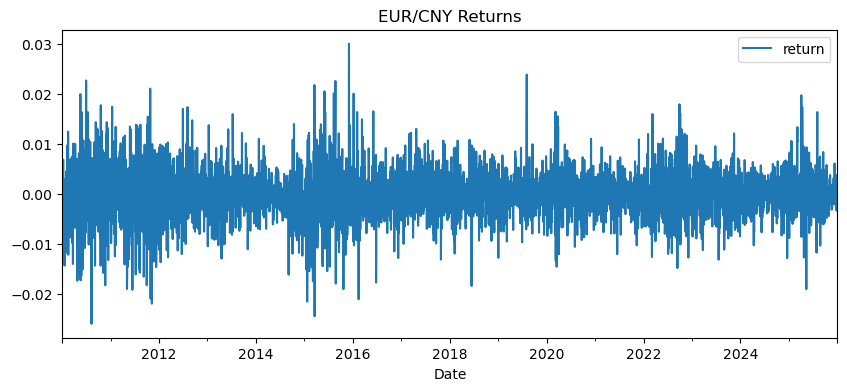

In [10]:
df.plot(x='Date', y='return', title='EUR/CNY Returns', figsize=(10,4))
plt.show()

In [11]:
# Rescale returns
r_scaled = df['return'].dropna() * 100

# Fit GARCH(1,1) with Student-t distribution
garch_scaled = arch_model(r_scaled, vol='GARCH', p=1, q=1, dist='t')
garch_res_scaled = garch_scaled.fit()
print(garch_res_scaled.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 147195.8561092265
Iteration:      2,   Func. Count:     16,   Neg. LLF: 157790.92612464752
Iteration:      3,   Func. Count:     25,   Neg. LLF: 4097.17403100896
Iteration:      4,   Func. Count:     34,   Neg. LLF: 2782.3582478535664
Iteration:      5,   Func. Count:     41,   Neg. LLF: 2779.0428796100064
Iteration:      6,   Func. Count:     48,   Neg. LLF: 2781.3692312992102
Iteration:      7,   Func. Count:     55,   Neg. LLF: 2780.281827871068
Iteration:      8,   Func. Count:     62,   Neg. LLF: 2773.4345633342064
Iteration:      9,   Func. Count:     69,   Neg. LLF: 2770.867270665295
Iteration:     10,   Func. Count:     76,   Neg. LLF: 2770.871077847837
Iteration:     11,   Func. Count:     83,   Neg. LLF: 2770.8427985795033
Iteration:     12,   Func. Count:     88,   Neg. LLF: 2770.842798579492
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2770.8427985795033
            Iterations

**Conclusion** : The GARCH(1,1) model has converged. The model found stable parameter estimates.

- Mean Model : The average daily return of EUR/CNY is statistically indistinguishable from zero.The exchange rate doesn’t show a consistent daily trend — it fluctuates around a stable mean. It's a typical result for FX data (short‑term returns are random, not directional).

- Volatility Model : 
𝛼_1+𝛽_1=0.995 -->  close to 1, hence volatility is highly persistent and therefore shocks fade slowly.


The volatility of EUR/CNY is sticky. This can be explained by :
1. China’s capital controls slow down adjustment
2. The RMB is not fully convertible
3. Policy interventions create lingering effects
4. Information transmission between Europe and China is slower

Because information and capital flows between Europe and China adjust slowly, shocks in one market do not immediately affect the other. This delayed transmission makes EUR/CNY volatility highly persistent.

- Distribution Model : We have a heavy‑tailed return distribution (ν ≈ 7.6). Hence, large shocks occur more often than a normal distribution predicts.

This can be explained by Policy shocks from the PBoC, dual market structure (CNY vs CNH), capital controls amplify shocks, geopolitical and macro events, and a slow transmission of information.


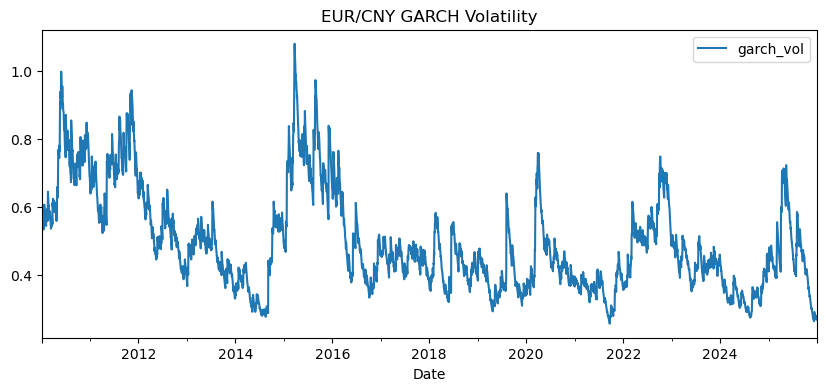

In [12]:
# Conditional volatility series
df['garch_vol'] = garch_res_scaled.conditional_volatility
df.plot(x='Date', y='garch_vol', title='EUR/CNY GARCH Volatility', figsize=(10,4))
plt.show()

In [13]:
df.to_csv(r"C:\Users\leler\Documents\Modeling EUR_CNY\eur_cny_with_vol.csv", index=False)

**Conclusion:** The plot of the conditional volatility of EUR/CNY estimated by a GARCH(1,1) model shows pronounced spikes around major macroeconomic and policy events (2012, 2015, 2020). The persistence of volatility confirms the slow adjustment of information and capital flows between Europe and China, consistent with partial market integration.

## Benchmark Analysis : EUR/USD

In [42]:
import pandas as pd
import numpy as np
from arch import arch_model
import matplotlib.pyplot as plt

file_path_usd = r"C:\Users\leler\Documents\Modeling EUR_CNY\EUR_USD Historical Data.csv"
eurusd = pd.read_csv(file_path_usd, sep=',', quotechar='"')
eurusd.rename(columns={'Price': 'Close'}, inplace=True)
eurusd['Date'] = pd.to_datetime(eurusd['Date'], dayfirst=False)
eurusd = eurusd.sort_values('Date').reset_index(drop=True)

#Log returns
eurusd['return'] = np.log(eurusd['Close'] / eurusd['Close'].shift(1))
eurusd = eurusd.dropna(subset=['return'])

In [47]:
from arch import arch_model
import matplotlib.pyplot as plt

#GARCH(1,1) model
r_usd = eurusd['return'] * 1000 
garch_usd = arch_model(r_usd, vol='GARCH', p=1, q=1, dist='t', rescale=False)
garch_usd_res = garch_usd.fit()
print(garch_usd_res.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 175356.72319206933
Iteration:      2,   Func. Count:     16,   Neg. LLF: 14050.841696360967
Iteration:      3,   Func. Count:     25,   Neg. LLF: 12828.093118171711
Iteration:      4,   Func. Count:     33,   Neg. LLF: 12480.159290273168
Iteration:      5,   Func. Count:     39,   Neg. LLF: 16762.567748288187
Iteration:      6,   Func. Count:     46,   Neg. LLF: 18973.559841259586
Iteration:      7,   Func. Count:     54,   Neg. LLF: 12477.11396940365
Iteration:      8,   Func. Count:     61,   Neg. LLF: 12473.590669605288
Iteration:      9,   Func. Count:     67,   Neg. LLF: 12473.467553535858
Iteration:     10,   Func. Count:     73,   Neg. LLF: 12473.464563493924
Iteration:     11,   Func. Count:     79,   Neg. LLF: 12473.461426438882
Iteration:     12,   Func. Count:     85,   Neg. LLF: 12473.460998571436
Iteration:     13,   Func. Count:     91,   Neg. LLF: 12473.460926025731
Iteration:     14,   Func. Count:     97,   Neg. LLF

Conclusion EUR/USD: The average daily return is equal to -0.0511, i.e. approximately zero and p-value equlas 0.437 which is not statitistical significant. There is a low volatility (omega equal to 0.0894).
Alpha[1] equals 0.0401, hence volatility reacts midly to new informations. And beta[1] equals  0.9572, hence persistence last long.
Overall, the volatility persistence is high (alpha[1]+beta[1] =0.9973). Hence shocks fades slowly.

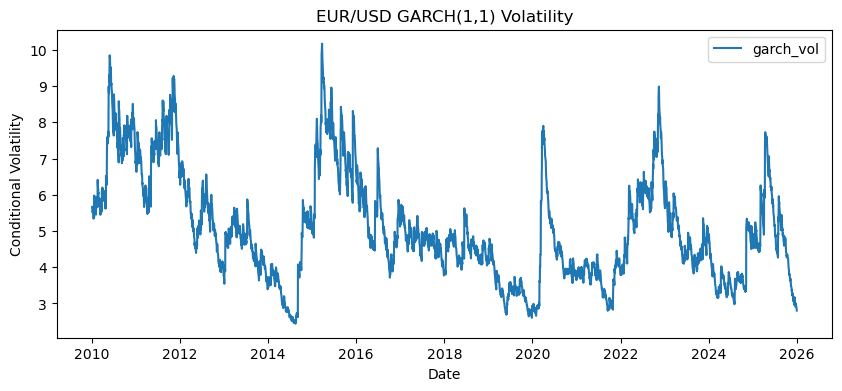

In [48]:
#Conditional volatility
eurusd['garch_vol'] = garch_usd_res.conditional_volatility

# Plot volatility
plt.figure(figsize=(10,4))
plt.plot(eurusd['Date'], eurusd['garch_vol'], label='garch_vol')
plt.title('EUR/USD GARCH(1,1) Volatility')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.legend()
plt.show()

The EUR/USD curve demonstrates a mature, globally integrated market where volatility reacts sharply to macro shocks (2010–2012, 2015–2016, 2020, 2022–2024) but reverts quickly

**Conclusion** : EUR/USD shows higher persistence but lower α, meaning shocks fade slower but are smaller. EUR/USD has fat tail but least extreme than EUR/CNY. Overall, EUR/USD is a mature and liquid FX market with smoother volatility dynamics than EUR/CNY.